---
title: "Catalog — raster / xarray / vector backends"
---

# Catalog backends — raster, xarray, vector on real data

Three builders share one `GeoCatalog` shape. This notebook builds a
catalog for each backend against **real public data**, then prints
the underlying GeoDataFrame so the substrate diversity is concrete:

| Backend | Real source |
|---|---|
| `build_raster_catalog` | Eight Sentinel-2 L2A scenes over Lake Tahoe (MPC) |
| `build_xarray_catalog` | Copernicus DEM GLO-30 tile over the same AOI, saved as a NetCDF |
| `build_vector_catalog` | Natural Earth admin-1 polygons (Pacific states) |

In [1]:
import tempfile
from pathlib import Path

import geocatalog as gc
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer
import pystac_client
import rioxarray
import xarray as xr

from geostack import (
    LAKE_TAHOE_BBOX,
    LAKE_TAHOE_TILE,
    load_natural_earth_admin1,
    load_stac_items,
)

tmp = Path(tempfile.mkdtemp(prefix="geocatalog_backends_"))
print(f"workdir: {tmp}")

workdir: /var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn/T/geocatalog_backends_kpb4r__u


## 1. Raster backend — real Sentinel-2 L2A scenes

Eight cloud-free scenes over Lake Tahoe (June–July 2024). The
catalog stores the **signed asset URLs**; pixel data is read lazily
on `load_raster`.

In [2]:
items = load_stac_items(
    "sentinel-2-l2a",
    LAKE_TAHOE_BBOX,
    "2024-06-01/2024-07-31",
    tile=LAKE_TAHOE_TILE,
    max_cloud_cover=15,
)
raster_cat = gc.build_raster_catalog(
    [it.assets["B04"].href for it in items],
    filename_regex=r".*_(?P<date>\d{8})T\d{6}_.*\.tif",
    target_crs="EPSG:32610",
)
print(raster_cat)
print(f"backend: {raster_cat.backend}")

InMemoryGeoCatalog(backend='raster', len=22, crs=<Projected CRS: EPSG:32610>
Name: WGS 84 / UTM zone 10N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 126°W and 120°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - British Columbia (BC); Northwest Territories (NWT); Nunavut; Yukon. United States (USA) - Alaska (AK).
- bounds: (-126.0, 0.0, -120.0, 84.0)
Coordinate Operation:
- name: UTM zone 10N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
)
backend: raster


The catalog is literally a `GeoDataFrame` — show it.

In [3]:
raster_cat.gdf[["filepath", "start_time", "end_time", "geometry"]].head()

,filepath,start_time,end_time,geometry
datetime,,,,
"[2024-07-29 00:00:00, 2024-07-29 23:59:59.999999]",https://sentinel2l2a01.blob.core.windows.net/s...,2024-07-29,2024-07-29 23:59:59.999999,"POLYGON ((809760 4290240, 809760 4400040, 6999..."
"[2024-06-14 00:00:00, 2024-06-14 23:59:59.999999]",https://sentinel2l2a01.blob.core.windows.net/s...,2024-06-14,2024-06-14 23:59:59.999999,"POLYGON ((809760 4290240, 809760 4400040, 6999..."
"[2024-07-09 00:00:00, 2024-07-09 23:59:59.999999]",https://sentinel2l2a01.blob.core.windows.net/s...,2024-07-09,2024-07-09 23:59:59.999999,"POLYGON ((809760 4290240, 809760 4400040, 6999..."
"[2024-06-29 00:00:00, 2024-06-29 23:59:59.999999]",https://sentinel2l2a01.blob.core.windows.net/s...,2024-06-29,2024-06-29 23:59:59.999999,"POLYGON ((809760 4290240, 809760 4400040, 6999..."
"[2024-06-04 00:00:00, 2024-06-04 23:59:59.999999]",https://sentinel2l2a01.blob.core.windows.net/s...,2024-06-04,2024-06-04 23:59:59.999999,"POLYGON ((809760 4290240, 809760 4400040, 6999..."


## 2. Xarray backend — Copernicus DEM

A real DEM tile saved to disk as NetCDF; bounds come from the coord
min/max, time from a configurable coordinate (default `"time"`).
We add a singleton-time dim so the xarray builder's time-aware path
is exercised even though a DEM is technically time-invariant.

In [4]:
mpc = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
dem_items = list(
    mpc.search(
        collections=["cop-dem-glo-30"],
        bbox=LAKE_TAHOE_BBOX,
    ).items()
)
dem = (
    rioxarray.open_rasterio(dem_items[0].assets["data"].href, masked=False)
    .squeeze("band", drop=True)
    .rio.clip_box(*LAKE_TAHOE_BBOX, crs="EPSG:4326")
)
nc_path = tmp / "cop_dem_lake_tahoe.nc"
ds = xr.Dataset(
    {"elevation": (("time", "y", "x"), dem.values[None, ...])},
    coords={
        "time": pd.date_range("2024-01-01", periods=1, freq="D"),
        "y": dem.y.values,
        "x": dem.x.values,
    },
)
ds.to_netcdf(nc_path)
print("Original xarray.Dataset:")
print(ds)

Original xarray.Dataset:
<xarray.Dataset> Size: 1MB
Dimensions:    (time: 1, y: 972, x: 360)
Coordinates:
  * time       (time) datetime64[us] 8B 2024-01-01
  * y          (y) float64 8kB 39.27 39.27 39.27 39.27 ... 39.0 39.0 39.0 39.0
  * x          (x) float64 3kB -120.1 -120.1 -120.1 ... -120.0 -120.0 -120.0
Data variables:
    elevation  (time, y, x) float32 1MB 2.047e+03 2.042e+03 ... 1.897e+03


In [5]:
xa_cat = gc.build_xarray_catalog(
    [nc_path], target_crs="EPSG:4326", data_vars=["elevation"], time_var="time"
)
print(xa_cat)
print(f"backend: {xa_cat.backend}")
print(f"n_timesteps: {int(xa_cat.gdf['n_timesteps'].iloc[0])}")
xa_cat.gdf

InMemoryGeoCatalog(backend='xarray', len=1, crs=<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
)
backend: xarray
n_timesteps: 1


,filepath,geometry,start_time,end_time,n_timesteps,time_var,data_vars,crs
datetime,,,,,,,,
"[2024-01-01 00:00:00, 2024-01-01 00:00:00]",/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn...,"POLYGON ((-120.00028 39.00028, -120.00028 39.2...",2024-01-01,2024-01-01,1,time,[elevation],EPSG:4326


## 3. Vector backend — Natural Earth admin-1 polygons

Polygon footprints come from each file's `total_bounds` in the
target CRS. We persist one GeoPackage per state so the catalog has
multiple rows.

In [6]:
ne = load_natural_earth_admin1()
pacific_states = ["California", "Oregon", "Nevada"]
vec_paths = []
for state in pacific_states:
    sub = ne[ne["name"] == state][["name", "geometry"]].copy()
    sub["class_id"] = pacific_states.index(state) + 1
    # Date-stamped filename so the regex picks up a date.
    p = tmp / f"admin1_{state.lower()}_20240101.gpkg"
    sub.to_file(p, driver="GPKG")
    vec_paths.append(p)
print(f"wrote {len(vec_paths)} admin GeoPackages to {tmp}")

wrote 3 admin GeoPackages to /var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn/T/geocatalog_backends_kpb4r__u


In [7]:
vec_cat = gc.build_vector_catalog(
    vec_paths,
    filename_regex=r"admin1_[a-z]+_(?P<date>\d{8})\.gpkg",
)
print(vec_cat)
print(f"backend: {vec_cat.backend}")
vec_cat.gdf

InMemoryGeoCatalog(backend='vector', len=3, crs=<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
)
backend: vector


,filepath,geometry,start_time,end_time,layer
datetime,,,,,
"[2024-01-01 00:00:00, 2024-01-01 23:59:59.999999]",/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn...,"POLYGON ((-114.16597 32.53533, -114.16597 41.9...",2024-01-01,2024-01-01 23:59:59.999999,None
"[2024-01-01 00:00:00, 2024-01-01 23:59:59.999999]",/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn...,"POLYGON ((-116.4578 41.99261, -116.4578 46.283...",2024-01-01,2024-01-01 23:59:59.999999,None
"[2024-01-01 00:00:00, 2024-01-01 23:59:59.999999]",/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn...,"POLYGON ((-114.02363 35.05311, -114.02363 42.0...",2024-01-01,2024-01-01 23:59:59.999999,None


## 4. Rasterising the labels over the Lake Tahoe AOI

`load_vector(..., task="semantic_segmentation")` turns the polygon
overlay into a label `GeoTensor` that lines up with any imagery
you load over the same AOI — the foundation for a vision-model
training pipeline.

label_tensor.values.shape: (1, 350, 170)
unique class IDs: [1, 3]


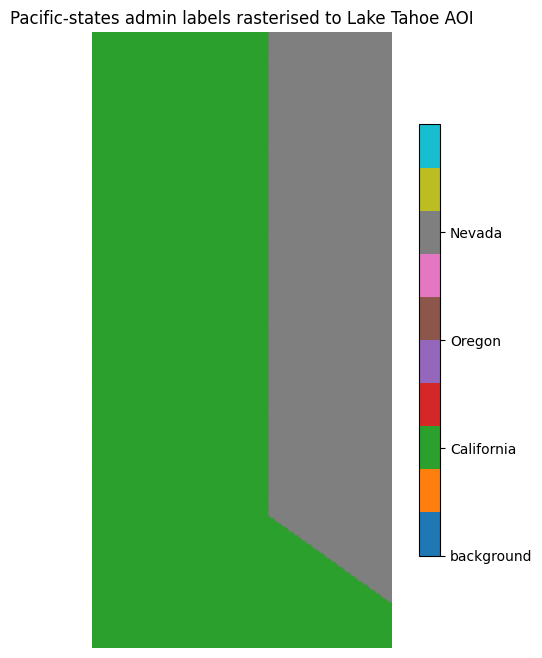

In [8]:
aoi = gc.GeoSlice(
    bounds=LAKE_TAHOE_BBOX,
    interval=pd.Interval(
        pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31"), closed="both"
    ),
    resolution=(0.001, 0.001),  # ~100 m at this latitude
    crs="EPSG:4326",
)
label_tensor = gc.load_vector(
    vec_cat, aoi, task="semantic_segmentation", label_field="class_id"
)
print(f"label_tensor.values.shape: {label_tensor.values.shape}")
print(f"unique class IDs: {sorted(np.unique(label_tensor.values).tolist())}")

fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(label_tensor.values[0], cmap="tab10", vmin=0, vmax=4)
ax.set_title("Pacific-states admin labels rasterised to Lake Tahoe AOI")
ax.axis("off")
cbar = fig.colorbar(im, ax=ax, shrink=0.7, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(["background", "California", "Oregon", "Nevada"])
plt.show()

## 5. GeoParquet roundtrip

Any catalog can be persisted as a GeoParquet artifact. The DuckDB
backend (see [04_duckdb](04_duckdb.ipynb)) reads the same format
directly without materialising the dataframe.

In [9]:
parquet_path = tmp / "raster_cat.parquet"
gc.to_geoparquet(raster_cat, parquet_path)
print(f"wrote {parquet_path.stat().st_size:,} bytes to {parquet_path}")

recovered = gc.from_geoparquet(parquet_path)
print(f"recovered: {recovered}")
print(f"len matches: {len(recovered) == len(raster_cat)}")

wrote 21,363 bytes to /var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn/T/geocatalog_backends_kpb4r__u/raster_cat.parquet


recovered: InMemoryGeoCatalog(backend='raster', len=22, crs=<Projected CRS: EPSG:32610>
Name: WGS 84 / UTM zone 10N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 126°W and 120°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - British Columbia (BC); Northwest Territories (NWT); Nunavut; Yukon. United States (USA) - Alaska (AK).
- bounds: (-126.0, 0.0, -120.0, 84.0)
Coordinate Operation:
- name: UTM zone 10N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
)
len matches: True


## Recap

Same `GeoCatalog` API, three substrates:

| Builder | Reads | Stores per row |
|---|---|---|
| `build_raster_catalog` | GeoTIFFs / `.vsicurl/` URLs | filepath, bounds (footprint polygon), time interval |
| `build_xarray_catalog` | NetCDF / zarr | filepath, bounds (from coord extent), time interval (from `time` coord), `n_timesteps` |
| `build_vector_catalog` | GeoPackage / Shapefile / Parquet | filepath, bounds (`total_bounds`), time interval |

All three round-trip through GeoParquet. All three implement the
same `GeoCatalog` Protocol — `query`, `intersect`, `union`,
`where`, `load_*` — so the [set algebra](03_set_algebra.ipynb) and
[patching bridge](05_patching_bridge.ipynb) demos work uniformly
regardless of which builder you used.